In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
# -------------------------
# 1. Count images by label
# -------------------------
def count_images(root):
    labels = ["Negative", "Neutral", "Positive"]
    total_counts = Counter()
    # print("Hey")
    files = os.listdir(root)
    # print(len(files))
    for file in files:
        if "negative" in file:
            total_counts["Negative"]+=1
        elif "neutral" in file:
            total_counts["Neutral"]+=1
        else:
            total_counts["Positive"]+=1
    
    return total_counts

In [4]:
# Run counting
root = "./../../../dataset/docimsent"
counts = count_images(root)
print("Image Distribution:", counts)

Image Distribution: Counter({'Positive': 627, 'Neutral': 562, 'Negative': 528})


In [5]:
# -------------- out of 1717 images ----------------------------
# \textit{\textcolor[HTML]{}{Negative}}: (528 instances)
# \textit{\textcolor[HTML]{}{Neutral}}: (562 instances)
# \textit{\textcolor[HTML]{}{Positive}}: (627 instances)


green = "d62728"
yellow = "febb78"
red = "2ca02c"

In [6]:
# -------------------------
# 2. Plot a hollow pie chart
# -------------------------
labels = list(counts.keys())
sizes = list(counts.values())

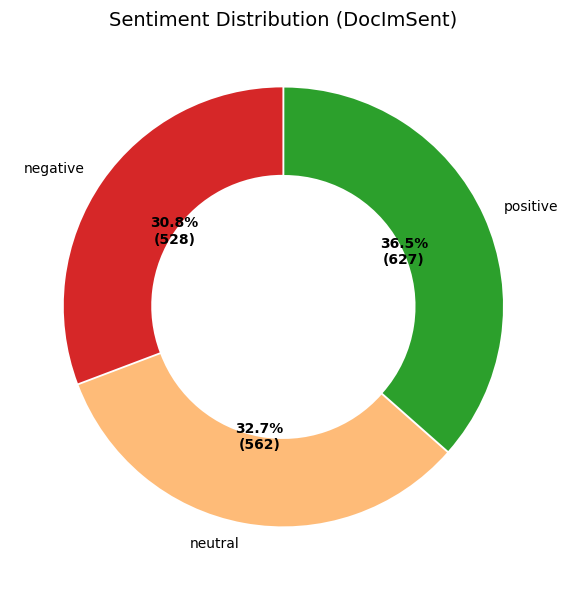

In [7]:
import matplotlib.pyplot as plt

# lowercase labels
labels = [lbl.lower() for lbl in labels]

# Your custom colors
colors = ["#d62728", "#febb78", "#2ca02c"]   # red, yellow, green

# Function to format labels with pct + count in bold
def make_autopct(values):
    def autopct_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return autopct_format

plt.figure(figsize=(6,6))

explode = [0.005, 0.005, 0.005]   # small gap between slices

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    startangle=90,
    wedgeprops=dict(width=0.4),
    autopct=make_autopct(sizes),
    textprops={'fontsize': 10}
)

# Make autopct text bold as well
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title("Sentiment Distribution (DocImSent)", fontsize=14)
plt.tight_layout()
plt.show()